In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = Path("D://projectLite/real_estate_val/notebooks/transactions-2025-03-21/transactions-2025-03-21.csv")
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (53481, 22)


,TRANSACTION_NUMBER,INSTANCE_DATE,GROUP_EN,PROCEDURE_EN,IS_OFFPLAN_EN,IS_FREE_HOLD_EN,USAGE_EN,AREA_EN,PROP_TYPE_EN,PROP_SB_TYPE_EN,TRANS_VALUE,PROCEDURE_AREA,ACTUAL_AREA,ROOMS_EN,PARKING,NEAREST_METRO_EN,NEAREST_MALL_EN,NEAREST_LANDMARK_EN,TOTAL_BUYER,TOTAL_SELLER,MASTER_PROJECT_EN,PROJECT_EN
0,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,160.62,160.62,2 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES
1,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,172.26,172.26,3 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES
2,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,140.05,140.05,3 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES
3,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,170.68,170.68,2 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES
4,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,117.58,117.58,3 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES


# Dataset overview: size, date range, transaction distribution

## Size

In [2]:
print("Dataset shape is :", df.shape)
print("\nColumns:\n", df.columns.tolist())

Dataset shape is : (53481, 22)

Columns:
 ['TRANSACTION_NUMBER', 'INSTANCE_DATE', 'GROUP_EN', 'PROCEDURE_EN', 'IS_OFFPLAN_EN', 'IS_FREE_HOLD_EN', 'USAGE_EN', 'AREA_EN', 'PROP_TYPE_EN', 'PROP_SB_TYPE_EN', 'TRANS_VALUE', 'PROCEDURE_AREA', 'ACTUAL_AREA', 'ROOMS_EN', 'PARKING', 'NEAREST_METRO_EN', 'NEAREST_MALL_EN', 'NEAREST_LANDMARK_EN', 'TOTAL_BUYER', 'TOTAL_SELLER', 'MASTER_PROJECT_EN', 'PROJECT_EN']


## Date range, transaction distribution

In [3]:
df["INSTANCE_DATE"] = pd.to_datetime(df["INSTANCE_DATE"], errors="coerce")

print("Date range:")
print("Start:", df["INSTANCE_DATE"].min())
print("End:", df["INSTANCE_DATE"].max())


Date range:
Start: 2025-01-01 21:47:23
End: 2025-03-21 11:44:59


## Transaction distribution

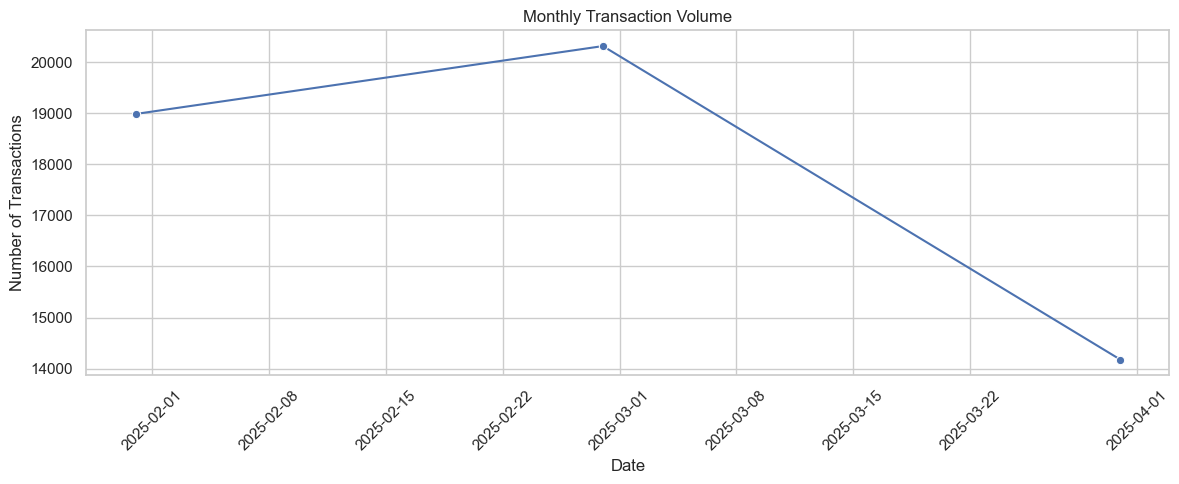

In [4]:
monthly_counts = (
    df.set_index("INSTANCE_DATE")["TRANS_VALUE"]
      .resample("ME")
      .count()
      .rename("transaction_count")
      .reset_index()
)

plt.figure(figsize=(12,5))
sns.lineplot(
    data=monthly_counts,
    x="INSTANCE_DATE",
    y="transaction_count",
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Missing Values & Data Quality

## Missing Values

In [5]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
}).sort_values("missing_percent", ascending=False)

missing_df[missing_df["missing_count"] > 0]


,missing_count,missing_percent
MASTER_PROJECT_EN,53382,99.814888
NEAREST_MALL_EN,25085,46.904508
NEAREST_METRO_EN,24665,46.119183
NEAREST_LANDMARK_EN,18553,34.690825
PARKING,15746,29.442232
ROOMS_EN,10023,18.741235
PROJECT_EN,7955,14.874441
PROP_SB_TYPE_EN,2372,4.435220


# Let's check for duplicacy 

In [6]:
int(df["TRANSACTION_NUMBER"].duplicated().sum())

1920

In [7]:
df[df["TRANSACTION_NUMBER"].duplicated() == True].head(1)

,TRANSACTION_NUMBER,INSTANCE_DATE,GROUP_EN,PROCEDURE_EN,IS_OFFPLAN_EN,IS_FREE_HOLD_EN,USAGE_EN,AREA_EN,PROP_TYPE_EN,PROP_SB_TYPE_EN,TRANS_VALUE,PROCEDURE_AREA,ACTUAL_AREA,ROOMS_EN,PARKING,NEAREST_METRO_EN,NEAREST_MALL_EN,NEAREST_LANDMARK_EN,TOTAL_BUYER,TOTAL_SELLER,MASTER_PROJECT_EN,PROJECT_EN
1,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,172.26,172.26,3 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES


In [8]:
df[df["TRANSACTION_NUMBER"]== '101-1-2025'].head(3)

,TRANSACTION_NUMBER,INSTANCE_DATE,GROUP_EN,PROCEDURE_EN,IS_OFFPLAN_EN,IS_FREE_HOLD_EN,USAGE_EN,AREA_EN,PROP_TYPE_EN,PROP_SB_TYPE_EN,TRANS_VALUE,PROCEDURE_AREA,ACTUAL_AREA,ROOMS_EN,PARKING,NEAREST_METRO_EN,NEAREST_MALL_EN,NEAREST_LANDMARK_EN,TOTAL_BUYER,TOTAL_SELLER,MASTER_PROJECT_EN,PROJECT_EN
0,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,160.62,160.62,2 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES
1,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,172.26,172.26,3 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES
2,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,140.05,140.05,3 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES


### It is stated that transaction number is unique, however we see that many datapoints exist with same transaction number and they have different ROOMS_EN and ACTUAL_AREA and PROCEDURE_AREA. We will proceed with the assumption that these datapoints belong to same transaction with multiple properties bought together

## Let's analyse missing categories

In [9]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
}).sort_values("missing_percent", ascending=False)

missing_df[missing_df["missing_count"] > 0]


,missing_count,missing_percent
MASTER_PROJECT_EN,53382,99.814888
NEAREST_MALL_EN,25085,46.904508
NEAREST_METRO_EN,24665,46.119183
NEAREST_LANDMARK_EN,18553,34.690825
PARKING,15746,29.442232
ROOMS_EN,10023,18.741235
PROJECT_EN,7955,14.874441
PROP_SB_TYPE_EN,2372,4.435220


### Let's analyse category MASTER_PROJECT_EN

In [10]:
print(df["MASTER_PROJECT_EN"].value_counts())
print(f"\n total count of these:{int(df["MASTER_PROJECT_EN"].value_counts().sum())}\n")


MASTER_PROJECT_EN
Elysee Heights                           46
Jebel Ali Village Townhouses- Phase 1    22
Remraam - Al Ramth                       14
JANNAT                                   10
Palace Beach Residence                    6
Hills Park                                1
Name: count, dtype: int64

 total count of these:99



### 99 datapoints in 53481 with available MASTER_PROJECT_EN, doesn't make sense to iuse it, let's drop it

In [11]:
df.drop(columns=["MASTER_PROJECT_EN"], inplace=True)


### Let's analyse category NEAREST_MALL_EN, NEAREST_METRO_EN, NEAREST_LANDMARK_EN

In [12]:
print(df["NEAREST_MALL_EN"].value_counts())
print(f"\n total count of these:{int(df["NEAREST_MALL_EN"].value_counts().sum())}\n")


NEAREST_MALL_EN
Marina Mall             10266
Dubai Mall               7221
Mall of the Emirates     5526
Ibn-e-Battuta Mall       3193
City Centre Mirdif       2190
Name: count, dtype: int64

 total count of these:28396



In [13]:
print(df["NEAREST_METRO_EN"].value_counts())
print(f"\n total count of these:{int(df["NEAREST_METRO_EN"].value_counts().sum())}\n")


NEAREST_METRO_EN
Dubai Internet City                     3349
Buj Khalifa Dubai Mall Metro Station    2962
Nakheel Metro Station                   2874
Business Bay Metro Station              2570
Damac Properties                        1800
Sharaf Dg Metro Station                 1652
First Abu Dhabi Bank Metro Station      1426
Jumeirah Lakes Towers                   1396
Rashidiya Metro Station                 1251
Creek Metro Station                      994
UAE Exchange Metro Station               976
Ibn Battuta Metro Station                889
Harbour Tower                            734
Marina Towers                            658
Jumeirah Beach Residency                 531
Marina Mall Metro Station                525
ENERGY Metro Station                     461
Mina Seyahi                              441
Palm Jumeirah                            410
Jumeirah Beach Resdency                  403
Al Jadaf Metro Station                   319
Dubai Marina                          

In [14]:
print(df["NEAREST_LANDMARK_EN"].value_counts())
print(f"\n total count of these:{int(df["NEAREST_LANDMARK_EN"].value_counts().sum())}\n")


NEAREST_LANDMARK_EN
Sports City Swimming Academy         9480
Downtown Dubai                       5007
IMG World Adventures                 4385
Burj Al Arab                         4354
Motor City                           3622
Expo 2020 Site                       2487
Burj Khalifa                         1788
Dubai International Airport          1725
Dubai Cycling Course                  917
Global Village                        480
Hamdan Sports Complex                 268
Al Makhtoum International Airport     261
Dubai Parks and Resorts               151
Jabel Ali                               3
Name: count, dtype: int64

 total count of these:34928



### they seem important with regards to selecting a proprty and we shouldn't drop them and rather fill the missing values with unknkown

In [15]:
location_cols = [
    "NEAREST_MALL_EN",
    "NEAREST_METRO_EN",
    "NEAREST_LANDMARK_EN"
]

for col in location_cols:
    df[col] = df[col].fillna("Unknown")


### Let's analyse category PARKING

In [16]:
print(df["PARKING"].value_counts())
print(f"\n total count of these:{int(df["PARKING"].value_counts().sum())}\n")


PARKING
1           18053
2            1359
1  0          281
EU            276
3              87
            ...  
14 3B 01        1
8-G-13          1
14GB25          1
14GA24          1
14 2B 24        1
Name: count, Length: 7825, dtype: int64

 total count of these:37735



### PARKING category is not numerical value completely, rather alphanumeric, we will keep numerical values only and set the other values as 0, we could also see that 14 2B 24  might mean one parking slot address and it could be 1, but that might add noise and so we will still keep those values as 0

In [17]:
df["PARKING"] = df["PARKING"].astype(str)

# Keep only fully numeric entries
df["PARKING_CLEAN"] = np.where(
    df["PARKING"].str.fullmatch(r"\d+"),
    df["PARKING"],
    np.nan
)

df["PARKING_CLEAN"] = pd.to_numeric(df["PARKING_CLEAN"], errors="coerce")

# Missing flag
df["parking_missing"] = df["PARKING_CLEAN"].isnull().astype(int)

# Fill missing with 0
df["PARKING_CLEAN"] = df["PARKING_CLEAN"].fillna(0).astype(int)

df.drop(columns=["PARKING"], inplace=True)
df.rename(columns={"PARKING_CLEAN": "PARKING"}, inplace=True)


### Let's analyse category ROOMS_EN

In [18]:
print(df["ROOMS_EN"].value_counts())
print(f"\n total count of these:{int(df["ROOMS_EN"].value_counts().sum())}\n")


ROOMS_EN
1 B/R        15592
2 B/R        10611
Studio        8022
3 B/R         5538
4 B/R         2328
Office         892
Shop           216
5 B/R          197
PENTHOUSE       41
6 B/R           13
7 B/R            4
GYM              4
Name: count, dtype: int64

 total count of these:43458



we can categorise them as residential and if they are residential we keep the number of rooms  

In [19]:
df["ROOMS_EN"] = df["ROOMS_EN"].astype(str).str.strip()
df["BEDROOMS"] = df["ROOMS_EN"].str.extract(r"(\d+)")
df["BEDROOMS"] = pd.to_numeric(df["BEDROOMS"], errors="coerce")
df.loc[df["ROOMS_EN"].str.contains("Studio", case=False, na=False), "BEDROOMS"] = 1
df["ROOM_TYPE"] = np.where(
    df["ROOMS_EN"].str.contains("Office|Shop|GYM|PENTHOUSE", case=False, na=False),
    df["ROOMS_EN"],
    "Residential"
)
df["BEDROOMS"] = df["BEDROOMS"].fillna(0)


In [20]:
print(df["BEDROOMS"].value_counts())
print(f"\n total count of these:{int(df["BEDROOMS"].value_counts().sum())}\n")



BEDROOMS
1.0    23614
0.0    11176
2.0    10611
3.0     5538
4.0     2328
5.0      197
6.0       13
7.0        4
Name: count, dtype: int64

 total count of these:53481



### Let's analyse category PROJECT_EN

In [21]:
print(df["PROJECT_EN"].value_counts())
print(f"\n total count of these:{int(df["PROJECT_EN"].value_counts().sum())}\n")


PROJECT_EN
Terra Heights                    731
DAMAC ISLANDS - BORA BORA 3      427
DAMAC HILLS (2) - VIOLET 3       406
The Valley - Farm Grove          385
La Tilia at Villanova Phase 2    383
                                ... 
SONDOS ORCHID                      1
SONDOS LILY                        1
SONDOS ROSA                        1
CLUB VILLAS                        1
EQUITI TOWER                       1
Name: count, Length: 2115, dtype: int64

 total count of these:45526



let's fill na with unknown

In [22]:
df['PROJECT_EN'] = df['PROJECT_EN'].fillna("Unknown")

### Let's analyse category PROP_SB_TYPE_EN

In [23]:
print(df["PROP_SB_TYPE_EN"].value_counts())
print(f"\n total count of these:{int(df["PROP_SB_TYPE_EN"].value_counts().sum())}\n")


PROP_SB_TYPE_EN
Flat                                                  36010
Villa                                                  5457
Residential                                            4146
Commercial                                             1546
Office                                                 1275
Hotel Apartment                                         681
Shop                                                    549
Land                                                    412
Hotel Rooms                                             338
Government Housing                                      258
Residential Flats                                        81
Residential / Attached Villas                            66
Airport                                                  62
Industrial                                               58
General Use                                              55
Unit                                                     26
Sports Club             

let's fill na with unknown

In [24]:
df['PROP_SB_TYPE_EN'] = df['PROP_SB_TYPE_EN'].fillna("Unknown")

In [25]:
df.head(2)

,TRANSACTION_NUMBER,INSTANCE_DATE,GROUP_EN,PROCEDURE_EN,IS_OFFPLAN_EN,IS_FREE_HOLD_EN,USAGE_EN,AREA_EN,PROP_TYPE_EN,PROP_SB_TYPE_EN,TRANS_VALUE,PROCEDURE_AREA,ACTUAL_AREA,ROOMS_EN,NEAREST_METRO_EN,NEAREST_MALL_EN,NEAREST_LANDMARK_EN,TOTAL_BUYER,TOTAL_SELLER,PROJECT_EN,PARKING,parking_missing,BEDROOMS,ROOM_TYPE
0,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,160.62,160.62,2 B/R,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NORTH FORTY THREE SERVICED RESIDENCES,1,0,2.0,Residential
1,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,172.26,172.26,3 B/R,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NORTH FORTY THREE SERVICED RESIDENCES,1,0,3.0,Residential


In [26]:
df["TRANS_VALUE"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 0.999])


count    5.348100e+04
mean     3.307043e+06
std      1.736951e+07
min      1.077000e+01
50%      1.589300e+06
75%      2.850000e+06
90%      4.764888e+06
95%      8.000000e+06
99%      2.800067e+07
99.5%    5.135802e+07
99.9%    1.400000e+08
max      1.578530e+09
Name: TRANS_VALUE, dtype: float64

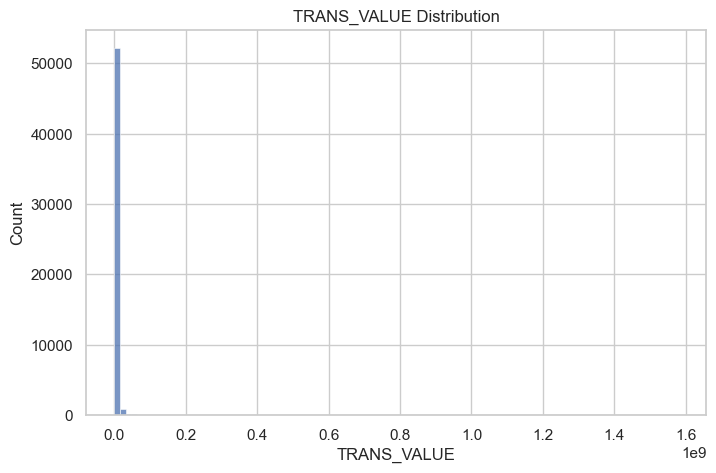

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["TRANS_VALUE"], bins=100)
plt.title("TRANS_VALUE Distribution")
plt.show()


as the dataset is heavily right skewed, we do log transform on the transactions

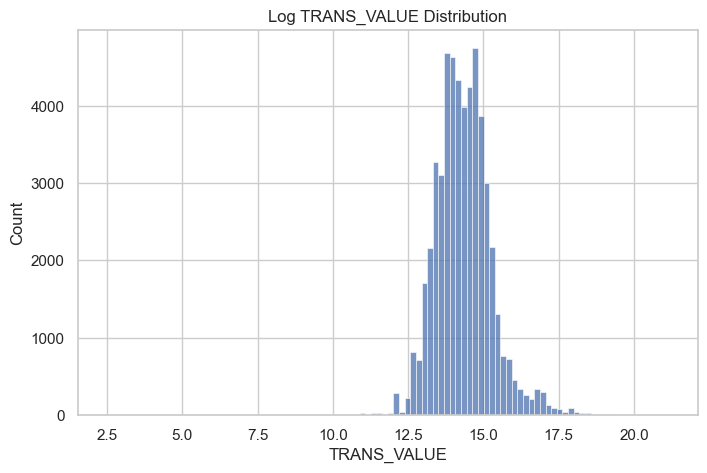

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["TRANS_VALUE"]), bins=100)
plt.title("Log TRANS_VALUE Distribution")
plt.show()


In [29]:
### Let's analyse Price trends by property type

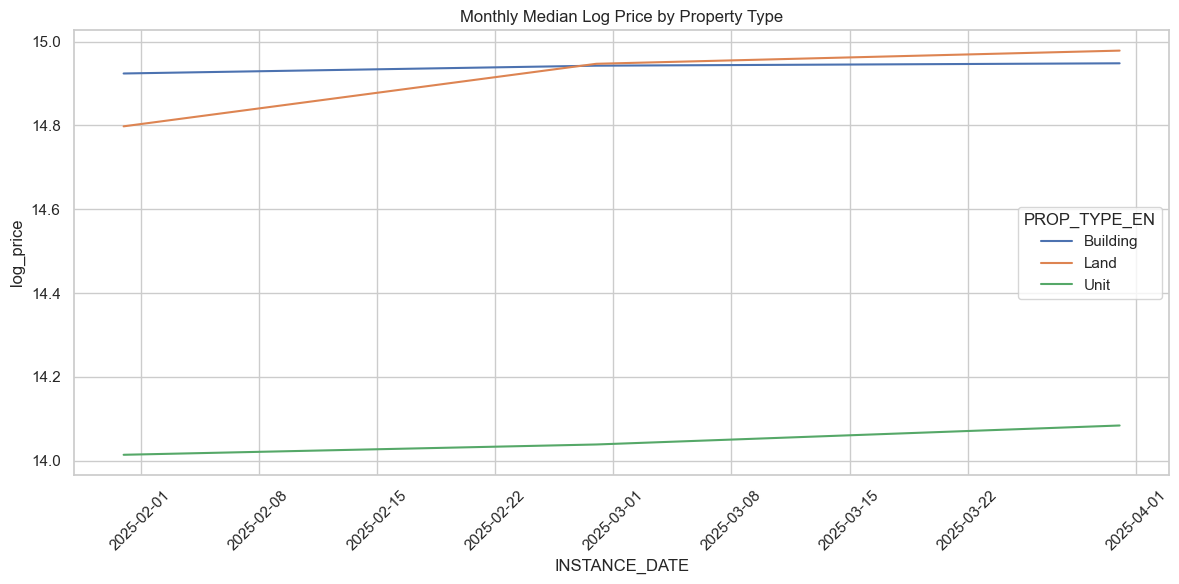

In [30]:
df["log_price"] = np.log1p(df["TRANS_VALUE"])

type_trend = (
    df.set_index("INSTANCE_DATE")
      .groupby("PROP_TYPE_EN")["log_price"]
      .resample("ME")
      .median()
      .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=type_trend,
    x="INSTANCE_DATE",
    y="log_price",
    hue="PROP_TYPE_EN"
)

plt.xticks(rotation=45)
plt.title("Monthly Median Log Price by Property Type")
plt.tight_layout()
plt.show()


Land shows the strongest upward trend, buildings remain stable, and units increase gradually. Property type also influences price.

### Let's analyse Price trends by property area
we group the areas by the median price for that area

In [31]:
area_median = df.groupby("AREA_EN")["TRANS_VALUE"].median().sort_values(ascending=False)
area_median.head(10)


AREA_EN
GRAND HILLS DUBAI             1.110000e+09
Al Safouh First               5.506750e+08
Mena Jabal Ali                5.190000e+08
Al Nahda First                1.050000e+08
Palm Jumeirah                 9.100250e+07
Al Eyas                       6.007425e+07
Muhaisanah Fourth             5.780000e+07
Ras Al Khor                   5.483871e+07
Al Qusais Industrial First    4.800000e+07
JUMEIRA BAY                   4.650000e+07
Name: TRANS_VALUE, dtype: float64

for analysis we do boxplot for 15 areas only

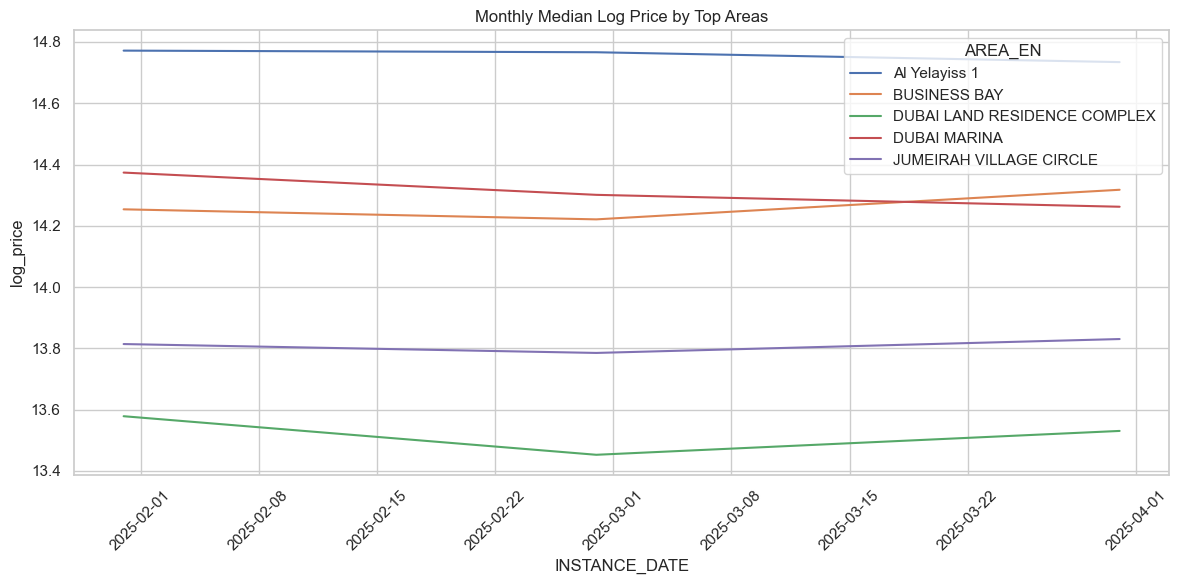

In [32]:
top_areas = df["AREA_EN"].value_counts().head(5).index

area_trend = (
    df[df["AREA_EN"].isin(top_areas)]
      .set_index("INSTANCE_DATE")
      .groupby("AREA_EN")["log_price"]
      .resample("ME")
      .median()
      .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=area_trend,
    x="INSTANCE_DATE",
    y="log_price",
    hue="AREA_EN"
)

plt.xticks(rotation=45)
plt.title("Monthly Median Log Price by Top Areas")
plt.tight_layout()
plt.show()


Top areas maintain almost consistent price levels, indicating consistent location-based pricing differences. Yes, area has major impact on prices

### Let's analyse Price trends by time


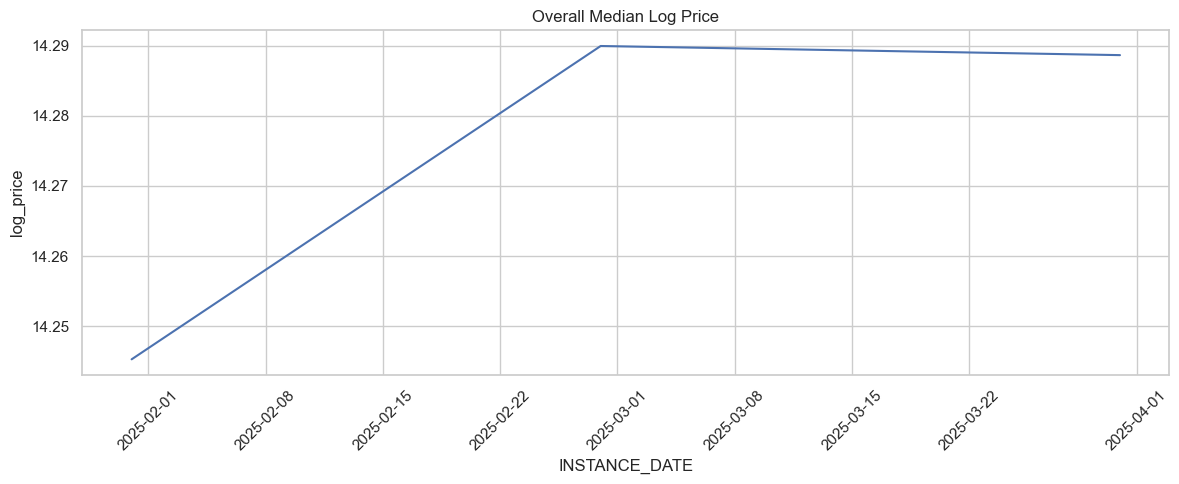

In [33]:
market_trend = (
    df.set_index("INSTANCE_DATE")["log_price"]
      .resample("ME")
      .median()
      .reset_index()
)

plt.figure(figsize=(12,5))
sns.lineplot(
    data=market_trend,
    x="INSTANCE_DATE",
    y="log_price"
)

plt.xticks(rotation=45)
plt.title("Overall Median Log Price")
plt.tight_layout()
plt.show()


The overall market shows a mild upward trend followed by stabilization, suggesting steady but modest appreciation.

metro Imapct

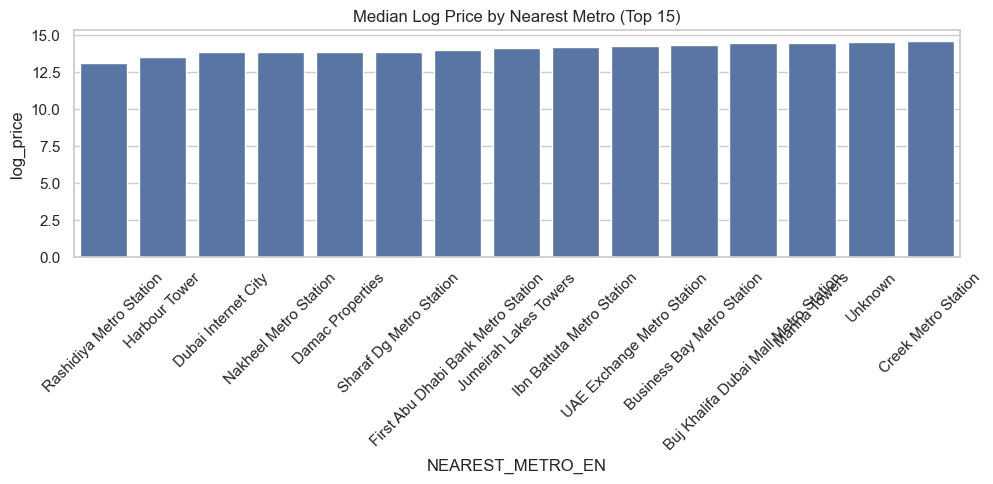

In [34]:
top_metro = df["NEAREST_METRO_EN"].value_counts().head(15).index

metro_median = (
    df[df["NEAREST_METRO_EN"].isin(top_metro)]
      .assign(log_price=np.log1p(df["TRANS_VALUE"]))
      .groupby("NEAREST_METRO_EN")["log_price"]
      .median()
      .sort_values()
      .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(data=metro_median, x="NEAREST_METRO_EN", y="log_price")
plt.xticks(rotation=45)
plt.title("Median Log Price by Nearest Metro (Top 15)")
plt.tight_layout()
plt.show()


Median prices vary slightly by metro station, but differences are relatively small, suggesting metro proximity has limited standalone impact.

Impact of Nearest mall Features

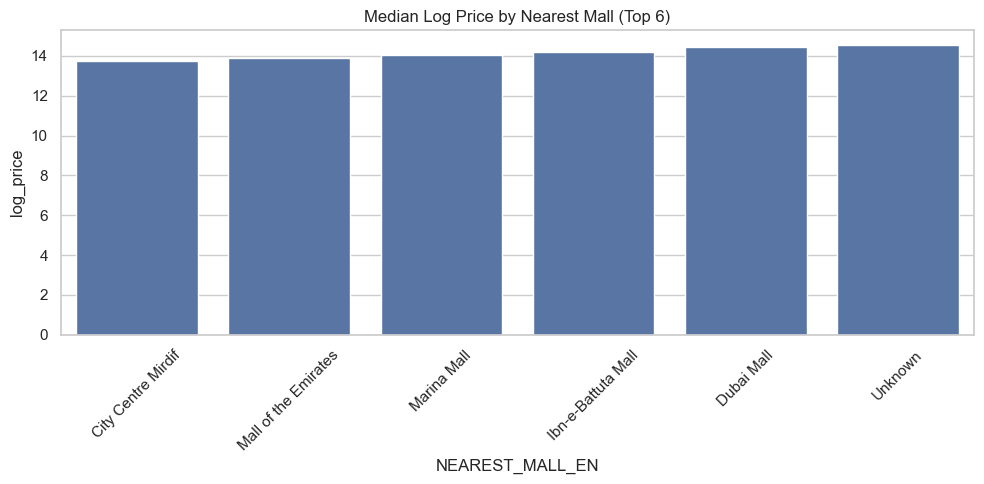

In [35]:
top_mall = df["NEAREST_MALL_EN"].value_counts().head(6).index

mall_median = (
    df[df["NEAREST_MALL_EN"].isin(top_mall)]
      .assign(log_price=np.log1p(df["TRANS_VALUE"]))
      .groupby("NEAREST_MALL_EN")["log_price"]
      .median()
      .sort_values()
      .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(data=mall_median, x="NEAREST_MALL_EN", y="log_price")
plt.xticks(rotation=45)
plt.title("Median Log Price by Nearest Mall (Top 6)")
plt.tight_layout()
plt.show()


Median prices across malls are very similar, indicating mall proximity contributes not much compared to other features.

Impact of of Nearest Landmark

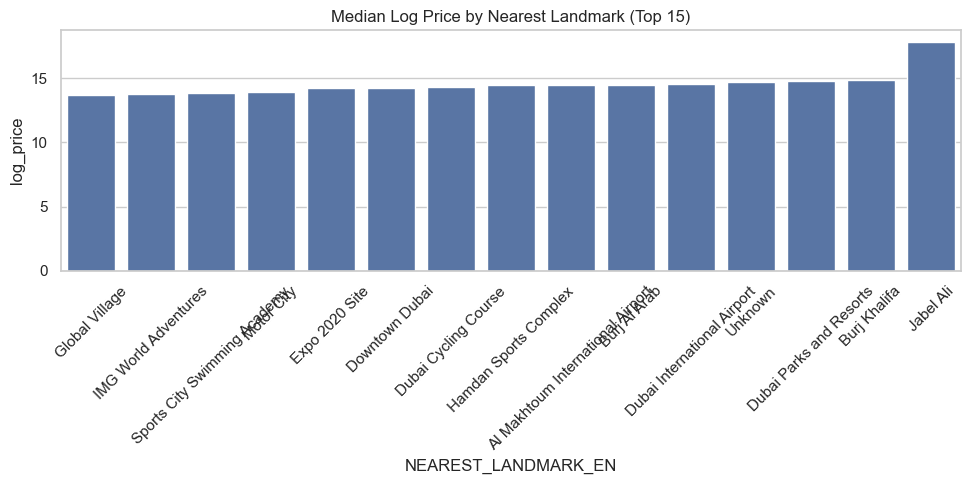

In [36]:
top_landmark = df["NEAREST_LANDMARK_EN"].value_counts().head(15).index

landmark_median = (
    df[df["NEAREST_LANDMARK_EN"].isin(top_landmark)]
      .assign(log_price=np.log1p(df["TRANS_VALUE"]))
      .groupby("NEAREST_LANDMARK_EN")["log_price"]
      .median()
      .sort_values()
      .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(data=landmark_median, x="NEAREST_LANDMARK_EN", y="log_price")
plt.xticks(rotation=45)
plt.title("Median Log Price by Nearest Landmark (Top 15)")
plt.tight_layout()
plt.show()


Some landmarks (e.g., Jebel Ali) show higher median prices, yet overall variation is stavle, indicating not a major influence individually

offplan vs Ready

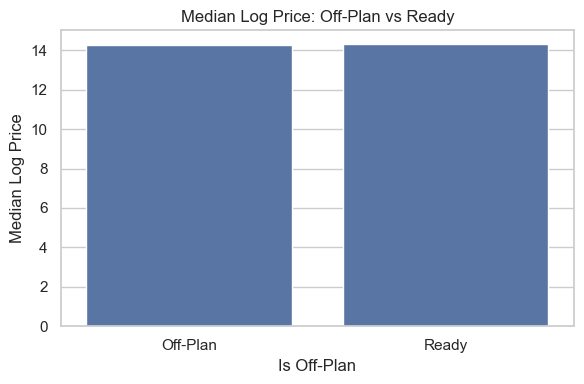

In [37]:
offplan_plot = (
    df.assign(log_price=np.log1p(df["TRANS_VALUE"]))
      .groupby("IS_OFFPLAN_EN")["log_price"]
      .median()
      .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=offplan_plot,
    x="IS_OFFPLAN_EN",
    y="log_price"
)

plt.title("Median Log Price: Off-Plan vs Ready")
plt.xlabel("Is Off-Plan")
plt.ylabel("Median Log Price")
plt.tight_layout()
plt.show()


Median prices are almost identical, indicating construction status has not much impact on pricing.

Freehold vs Leasehold

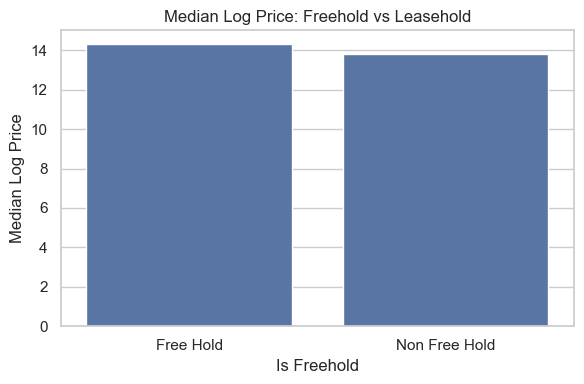

In [38]:
freehold_plot = (
    df.assign(log_price=np.log1p(df["TRANS_VALUE"]))
      .groupby("IS_FREE_HOLD_EN")["log_price"]
      .median()
      .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=freehold_plot,
    x="IS_FREE_HOLD_EN",
    y="log_price"
)

plt.title("Median Log Price: Freehold vs Leasehold")
plt.xlabel("Is Freehold")
plt.ylabel("Median Log Price")
plt.tight_layout()
plt.show()


Freehold properties show a clear pricing difference over leasehold, suggesting ownership rights impact transaction value.

we don't derive price per sqm, becuase we would be using actual Y values derivatives in X and that would highly influence the final result so we skip creating the feature "price per sqm"

# More Feature Engineering

In [39]:

# -------------------
#we take log of TRANS_VALUE
df["log_price"] = np.log1p(df["TRANS_VALUE"])

# ---------- Time Features ----------
df["INSTANCE_DATE"] = pd.to_datetime(df["INSTANCE_DATE"])
df["year"] = df["INSTANCE_DATE"].dt.year
df["month"] = df["INSTANCE_DATE"].dt.month

# ---------- Drop Useless Columns ----------
df = df.drop(columns=[
    "TRANSACTION_NUMBER",
    "GROUP_EN",
    "PROCEDURE_EN"
])
# ---------- One-Hot (Low Cardinality) ----------
low_card_cols = [
    "IS_OFFPLAN_EN",
    "IS_FREE_HOLD_EN",
    "USAGE_EN",
    "PROP_TYPE_EN",
    "ROOM_TYPE"
]

df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

# ---------- Target Encoding: AREA ----------
area_mean = df.groupby("AREA_EN")["log_price"].mean()
df["AREA_TE"] = df["AREA_EN"].map(area_mean)

# ---------- PROJECT: Keep Top 30 + Target Encode ----------
top_projects = df["PROJECT_EN"].value_counts().head(30).index
df["PROJECT_EN"] = df["PROJECT_EN"].where(
    df["PROJECT_EN"].isin(top_projects),
    "Other"
)

project_mean = df.groupby("PROJECT_EN")["log_price"].mean()
df["PROJECT_TE"] = df["PROJECT_EN"].map(project_mean)

# ---------- METRO ----------
top_metro = df["NEAREST_METRO_EN"].value_counts().head(20).index
df["NEAREST_METRO_EN"] = df["NEAREST_METRO_EN"].where(
    df["NEAREST_METRO_EN"].isin(top_metro),
    "Other"
)

metro_mean = df.groupby("NEAREST_METRO_EN")["log_price"].mean()
df["METRO_TE"] = df["NEAREST_METRO_EN"].map(metro_mean)

# ---------- MALL ----------
top_mall = df["NEAREST_MALL_EN"].value_counts().head(20).index
df["NEAREST_MALL_EN"] = df["NEAREST_MALL_EN"].where(
    df["NEAREST_MALL_EN"].isin(top_mall),
    "Other"
)

mall_mean = df.groupby("NEAREST_MALL_EN")["log_price"].mean()
df["MALL_TE"] = df["NEAREST_MALL_EN"].map(mall_mean)

# ---------- LANDMARK ----------
top_landmark = df["NEAREST_LANDMARK_EN"].value_counts().head(20).index
df["NEAREST_LANDMARK_EN"] = df["NEAREST_LANDMARK_EN"].where(
    df["NEAREST_LANDMARK_EN"].isin(top_landmark),
    "Other"
)

landmark_mean = df.groupby("NEAREST_LANDMARK_EN")["log_price"].mean()
df["LANDMARK_TE"] = df["NEAREST_LANDMARK_EN"].map(landmark_mean)

df = df.sort_values("INSTANCE_DATE")

# ---------- Drop Raw Categorical ----------
df = df.drop(columns=[
    "AREA_EN",
    "PROJECT_EN",
    "NEAREST_METRO_EN",
    "NEAREST_MALL_EN",
    "NEAREST_LANDMARK_EN",
    "PROP_SB_TYPE_EN",
    "ROOMS_EN",
    "TRANS_VALUE",
    "INSTANCE_DATE"
])

# splitting train test
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(columns=["log_price"])
y_train = train["log_price"]

X_test = test.drop(columns=["log_price"])
y_test = test["log_price"]

# ---------- Model ----------
model = LGBMRegressor()
model.fit(X_train, y_train)

NameError: name 'LGBMRegressor' is not defined

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(X_test)

print("MAE (log scale):", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))


In [ ]:
real_pred = np.expm1(pred)
real_y = np.expm1(y_test)

print("MAE (real price):", mean_absolute_error(real_y, real_pred))


In [ ]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(15))
